In [1]:
#imports 

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Load data and merge (DON'T NEED ALL THIS WHEN FILES ARE UPLOADED IN ZERVE)

weather = pd.read_csv("weather.csv")
eia_df = pd.read_csv("eia.csv")

weather["datetime"] = pd.to_datetime(weather["datetime"])
eia_df["datetime"] = pd.to_datetime(eia_df["datetime"])

merged_df = pd.merge(weather, eia_df, on="datetime", how="inner")
merged_df.head()

,temperature,humidity,apparent_temperature,datetime,hour,month,demand_mwh
0,8.1,77,5.0,2022-01-01 00:00:00,0,1,22618.0
1,6.3,79,3.4,2022-01-01 01:00:00,1,1,24545.0
2,5.2,77,2.4,2022-01-01 02:00:00,2,1,27081.0
3,5.0,76,2.1,2022-01-01 03:00:00,3,1,27153.0
4,3.7,80,0.8,2022-01-01 04:00:00,4,1,26522.0


In [3]:
merged_df.describe()
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 26328 entries, 0 to 26327
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   temperature           26328 non-null  float64       
 1   humidity              26328 non-null  int64         
 2   apparent_temperature  26328 non-null  float64       
 3   datetime              26328 non-null  datetime64[ns]
 4   hour                  26328 non-null  int64         
 5   month                 26328 non-null  int64         
 6   demand_mwh            26323 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(3)
memory usage: 1.6 MB


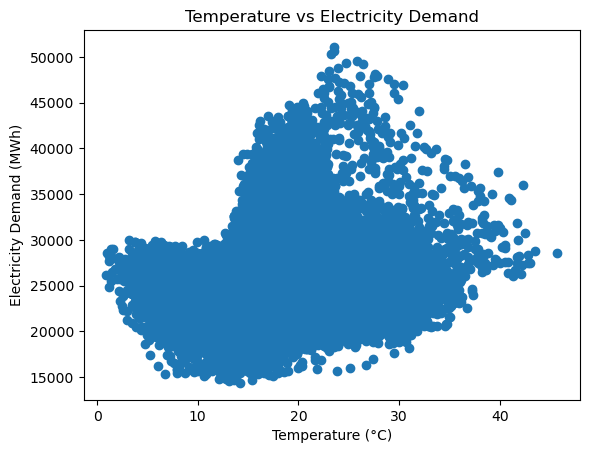

In [4]:
#Temperature vs. Demand plot (Does higher temperature lead to higher electricity demand?)

plt.scatter(merged_df["temperature"], merged_df["demand_mwh"])
plt.xlabel("Temperature (°C)")
plt.ylabel("Electricity Demand (MWh)")
plt.title("Temperature vs Electricity Demand")
plt.show()

Through the scatter plot above, it is shown that at low temperatures (0–10°C), demand is fairly high (around 25,000–30,000 MWh). This is due to people heating their homes in the winter. Then demand drops through the mild 15–20°C range because nobody needs heating or cooling. Then it shoots back up past 25°C as people start using air conditioning, peaking around 45,000–50,000 MWh at the hottest temperatures.

The relationship shows is a U-shaped relationship and is exactly what you'd expect from California's climate.

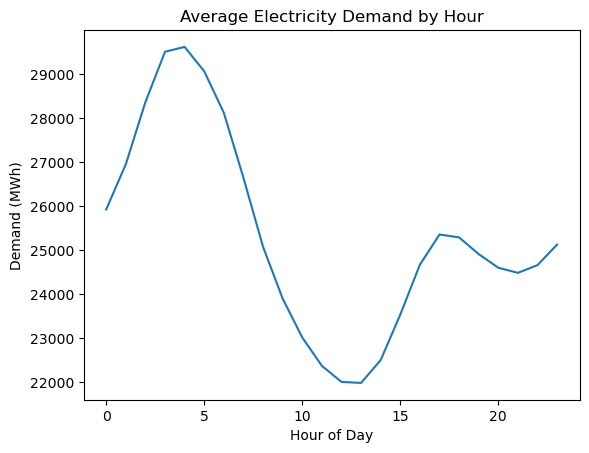

In [5]:
#Hourly demand pattern (Do heatwave conditions increase electricity usage?)

merged_df.groupby("hour")["demand_mwh"].mean().plot()

plt.title("Average Electricity Demand by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Demand (MWh)")
plt.show()

Through the graph above, it is clear that demand peaks around 3–4 AM (~29,500 MWh), then drops at around noon (~22,000 MWh), and then slightly rises again in the evening. 

That being said, the EIA reports electricity in UTC time, not local California time. California is UTC-8 in winter and UTC-7 in summer, so that 3–4 AM peak in the data is actually 7–8 PM local time, which is exactly when you'd expect evening peak demand. The noon drop is actually around 4–5 AM local time when everyone's asleep.

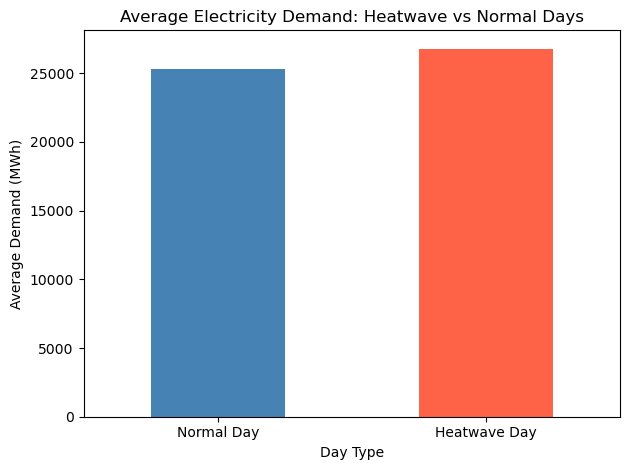

In [6]:
#Heatwave vs. Normal Day (heatwave = temperature >= 32C)

merged_df["heatwave_flag"] = (merged_df["temperature"] >= 32).astype(int)

heatwave_demand = merged_df.groupby("heatwave_flag")["demand_mwh"].mean()
heatwave_demand.index = ["Normal Day", "Heatwave Day"]

heatwave_demand.plot(kind="bar", color=["steelblue", "tomato"])
plt.title("Average Electricity Demand: Heatwave vs Normal Days")
plt.xlabel("Day Type")
plt.ylabel("Average Demand (MWh)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


For the graph above, heatwave days (≥32°C) average around 27,000 MWh while normal days average around 25,500 MWh, thats around a 6% increase during heatwave days. This makes sense as the difference is not enormous indicating that not every heatwave hour is a peak demand hour (a 3 AM heatwave doesn't drive much AC usage), so averaging across all 24 hours dilutes the effect. 

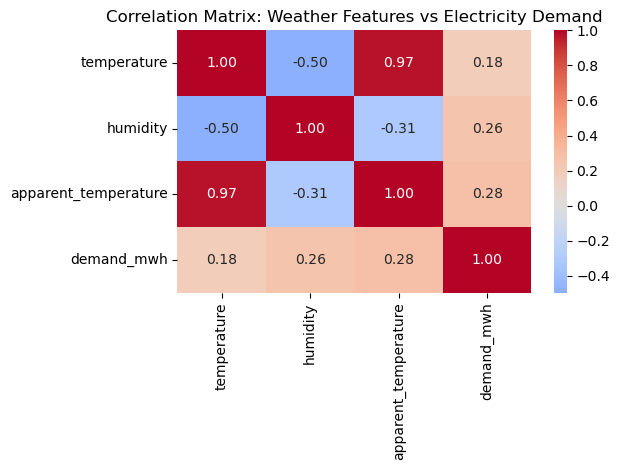

In [7]:
#Correlation heatmap: how strongly do weather features relate to demand?

corr = merged_df[["temperature", "humidity", "apparent_temperature", "demand_mwh"]].corr()

sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix: Weather Features vs Electricity Demand")
plt.tight_layout()
plt.show()


The above shows how strongly each weather variable relates to the others and to demand. A value of 1.0 means perfectly correlated, -1.0 means perfectly opposite, and 0 means no relationship.

- Temperature → demand: 0.18 — weak positive correlation. Higher temp = slightly more demand, but it's not a strong linear relationship
- Humidity → demand: 0.26 — slightly stronger than temperature alone. Humid heat is harder to bear, so more people turn on the AC.
- Apparent temperature → demand: 0.28 — the strongest of the three, which validates using it as a feature. The "feels like" temperature is a better predictor than raw temperature because it captures the combined effect of heat and humidity.
